In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing

In [2]:
df = pd.read_excel("../data/raw/Online_retail.xlsx")

In [4]:
df.columns = df.columns.str.lower()

In [11]:
df['revenue'] = df['quantity'] * df['unitprice']

In [5]:
df = df.dropna(subset=["customerid"])

In [6]:
df = df[df["quantity"] > 0]

In [7]:
df = df[df["unitprice"] > 0]

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(392692, 8)

In [12]:
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["revenue"] >= lower) & (df["revenue"] <= upper)]

<Axes: >

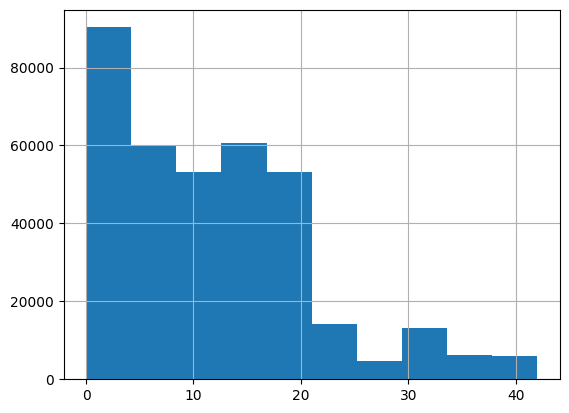

In [13]:
df["revenue"].hist()

## RFM Analysis

In [14]:
snapshot_date = df["invoicedate"].max()

rfm = df.groupby("customerid").agg({
    "invoicedate": lambda x: (snapshot_date - x.max()).days,
    "invoiceno": "count",
    "revenue": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]

## Rolling Ststistics

In [16]:
daily_sales = df.groupby(df["invoicedate"].dt.date)["revenue"].sum()

rolling_mean = daily_sales.rolling(window=7).mean()

rolling_std = daily_sales.rolling(window=7).std()

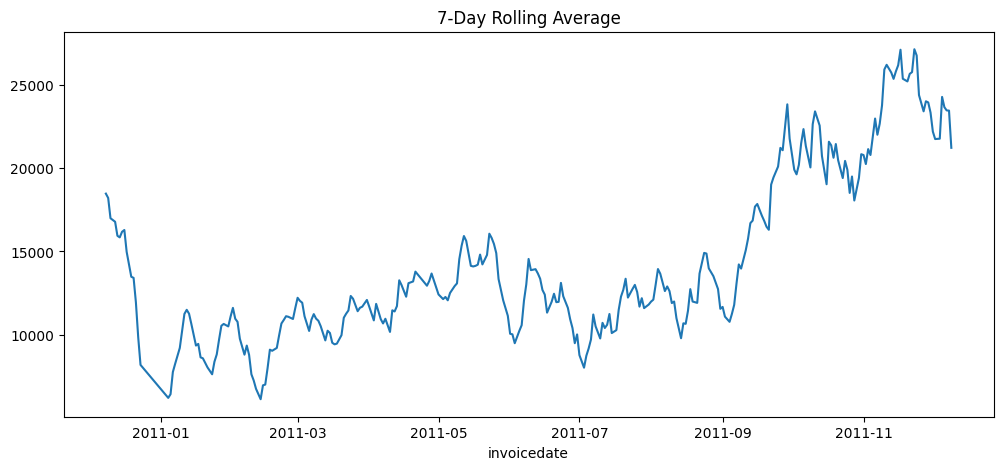

In [17]:
rolling_mean.plot(figsize=(12,5))
plt.title("7-Day Rolling Average")
plt.show()

In [19]:
rfm.to_csv("../data/processed/rfm_features.csv",index=False)
df.to_csv("../data/processed/cleaned_retail.csv", index=False)